### Numpy array vs Python lists


In [2]:
# speed : Numpy array is way more faster than the normal pythonic array . It is due to the dynamic Size nature and storing refenrece pointer of data in ML in array element thus  need extra time to access elements
# list
a = [i for i in range(10000000)]
b = [i for i in range(10000000, 20000000)]

c = []
import time

start = time.time()
print(start, "startTime")
for i in range(len(a)):
    c.append(a[i] + b[i])
end = time.time()
print(end, "EndTime")
print(end - start)

1779597789.7537227 startTime
1779597790.7542474 EndTime
1.0005247592926025


In [3]:
# numpy
import numpy as np

a = np.arange(10000000)
b = np.arange(10000000, 20000000)

start = time.time()
c = a + b
print(time.time() - start)

0.06950926780700684


In [4]:
0.91 / 0.05

18.2

In [5]:
# memory  : both takes similar memory but ewith help of dType in numpy we can reduce size of array if needed 
a = [i for i in range(10000000)]
import sys

sys.getsizeof(a)

89095160

In [6]:
a = np.arange(10000000, dtype=np.int8) #default is inter64
sys.getsizeof(a)

10000112

In [7]:
# convenience : numpy is more conviniet 

### Advanced Indexing


In [14]:
# Normal Indexing and slicing

a = np.arange(12).reshape(4, 3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [15]:
a[1, 2]

5

In [16]:
a[1:3, 1:3]

array([[4, 5],
       [7, 8]])

In [17]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [27]:
# Fancy Indexing :  when no patter for indexing then pass which rows/col you want in  a arrya
print(a[[0,1,3] , : ]) # --> Selects row 0 1and 3 and all col element of each rom
print("XX")
print(a[[0,1,3] , 2 ]) # --> Selects row 0 1and 3 and only lasr col element of each rom
print("XX")
# print(a[[0,1,3] , [0,1] ]) == > will not work
print(a[: , [1,2]])

[[ 0  1  2]
 [ 3  4  5]
 [ 9 10 11]]
XX
[ 2  5 11]
XX
[[ 1  2]
 [ 4  5]
 [ 7  8]
 [10 11]]


In [29]:
# Boolean Indexing
a = np.random.randint(1, 100, 24).reshape(6, 4)
a

array([[59, 95, 61, 74],
       [48, 90, 26,  6],
       [24, 14, 81, 25],
       [84, 56, 12,  2],
       [76, 86, 34, 50],
       [36, 96, 53, 30]])

In [ ]:
a>50 # in last class    # impose boolen array on the numpy araay  

array([[ True,  True,  True,  True],
       [False,  True, False, False],
       [False, False,  True, False],
       [ True,  True, False, False],
       [ True,  True, False, False],
       [False,  True,  True, False]])

In [34]:
# find all numbers greater than 50
a[a > 50]

array([59, 95, 61, 74, 90, 81, 84, 56, 76, 86, 96, 53])

In [35]:
# find out even numbers
a[a % 2 == 0]

array([74, 48, 90, 26,  6, 24, 14, 84, 56, 12,  2, 76, 86, 34, 50, 36, 96,
       30])

In [ ]:
# find all numbers greater than 50 and are even

a[(a > 50) & (a % 2 == 0)] # & -> bit wise and


#a > 50 → create boolean array
# a % 2 == 0 → create another boolean array
# & combines them element-wise

array([74, 90, 84, 56, 76, 86, 96])

In [39]:
# find all numbers not divisible by 7
a[~(a % 7 == 0)]

array([59, 95, 61, 74, 48, 90, 26,  6, 24, 81, 25, 12,  2, 76, 86, 34, 50,
       36, 96, 53, 30])

### Broadcasting

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is “broadcast” across the larger array so that they have compatible shapes.


In [1]:
# same shape
a = np.arange(6).reshape(2, 3)
b = np.arange(6, 12).reshape(2, 3)

print(a)
print(b)

print(a + b)
print(a*b) # elem wise multiply
print(np.dot(a,b.reshape(3,2))) # dot product of Matrix

NameError: name 'np' is not defined

In [43]:
# diff shape
a = np.arange(6).reshape(2, 3)
b = np.arange(3).reshape(1, 3)

print(a)
print(b)
print("XXXXXXXXX")
print(a + b)

[[0 1 2]
 [3 4 5]]
[[0 1 2]]
XXXXXXXXX
[[0 2 4]
 [3 5 7]]


#### Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**<br>

- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.<br>


**2. Make each dimension of the two arrays the same size.**<br>

- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.


<img src = "    ">


In [11]:
# More examples

a = np.arange(12).reshape(4, 3)
b = np.arange(3)

print(a)
print(b)

print(a + b)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[0 1 2]
[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [12]:
a = np.arange(12).reshape(3, 4)
b = np.arange(3)

print(a)
print(b)

print(a + b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2]


ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [ ]:
a = np.arange(3).reshape(1, 3)
b = np.arange(3).reshape(3, 1)

print(a)
print(b)

print(a + b)

[[0 1 2]]
[[0]
 [1]
 [2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [13]:
a = np.arange(3).reshape(1, 3)
b = np.arange(4).reshape(4, 1)

print(a)
print(b)

print(a + b)

[[0 1 2]]
[[0]
 [1]
 [2]
 [3]]
[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [14]:
a = np.array([1])
# shape -> (1,1)
b = np.arange(4).reshape(2, 2)
# shape -> (2,2)

print(a)
print(b)

print(a + b)

[1]
[[0 1]
 [2 3]]
[[1 2]
 [3 4]]


In [15]:
a = np.arange(12).reshape(3, 4)
b = np.arange(12).reshape(4, 3)

print(a)
print(b)

print(a + b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


ValueError: operands could not be broadcast together with shapes (3,4) (4,3) 

In [ ]:
a = np.arange(16).reshape(4, 4)
b = np.arange(4).reshape(2, 2)

print(a)
print(b)

print(a + b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[0 1]
 [2 3]]


ValueError: ignored

### Working with mathematical formulas


In [106]:
a = np.arange(10)
np.sin(a)

array([ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
       -0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849])

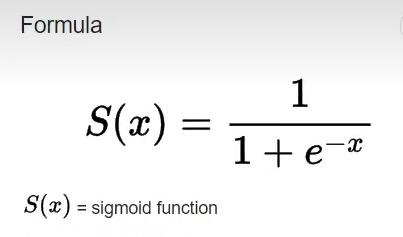

In [107]:
# sigmoid
def sigmoid(array):
    return 1 / (1 + np.exp(-(array)))


a = np.arange(10)

sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661])

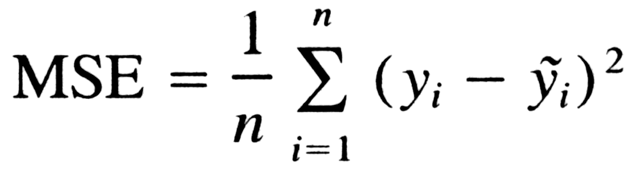

In [108]:
# mean squared error

actual = np.random.randint(1, 50, 25)
predicted = np.random.randint(1, 50, 25)

In [109]:
def mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)


mse(actual, predicted)

443.6

In [110]:
# binary cross entropy
np.mean((actual - predicted) ** 2)

443.6

In [111]:
actual

array([ 3, 18, 36,  2, 24, 31, 47, 38,  6, 28, 19, 43, 13,  4, 12,  2, 44,
       34, 18, 29, 49,  8, 41, 38, 20])

### Working with missing values


In [ ]:
# Working with missing values -> np.nan
a = np.array([1, 2, 3, 4, np.nan, 6])
a

array([ 1.,  2.,  3.,  4., nan,  6.])

In [ ]:
a[~np.isnan(a)]

array([1., 2., 3., 4., 6.])

### Plotting Graphs


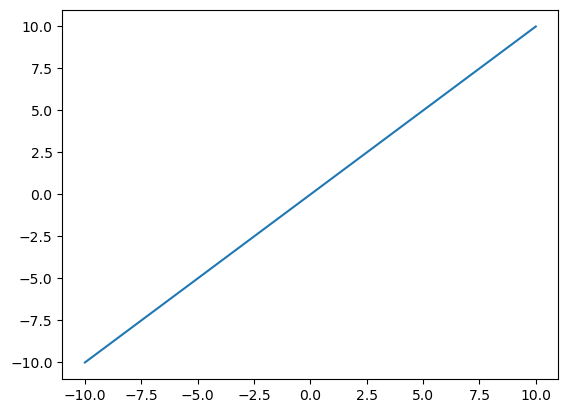

In [93]:
# plotting a 2D plot
# x = y
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = x

plt.plot(x, y)

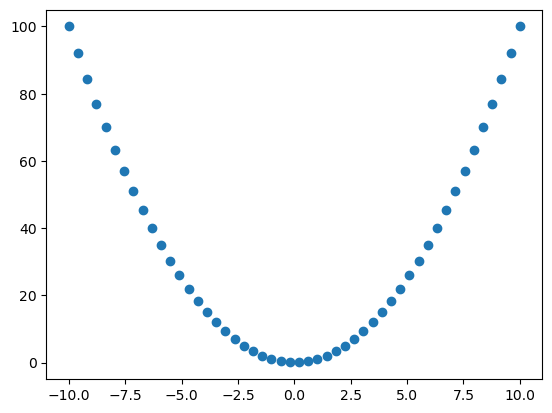

In [96]:
# y = x^2
x = np.linspace(-10, 10, 50)
y = x**2

plt.scatter(x, y)

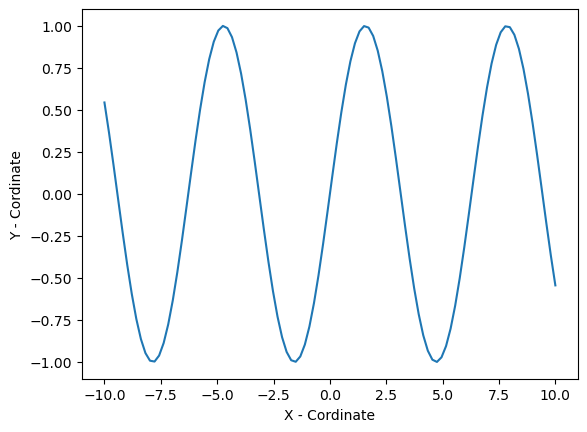

In [97]:
# y = sin(x)
x = np.linspace(-10, 10, 100)
y = np.sin(x)
plt.xlabel("X - Cordinate")
plt.ylabel("Y - Cordinate")
plt.plot(x, y)

C:\Users\anish\AppData\Local\Temp\ipykernel_25408\4242457434.py:3: RuntimeWarning: invalid value encountered in log
  y = x * np.log(x)


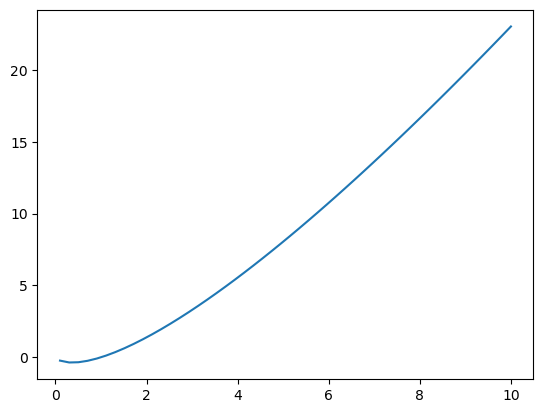

In [98]:
# y = xlog(x)
x = np.linspace(-10, 10, 100)
y = x * np.log(x)

plt.plot(x, y)

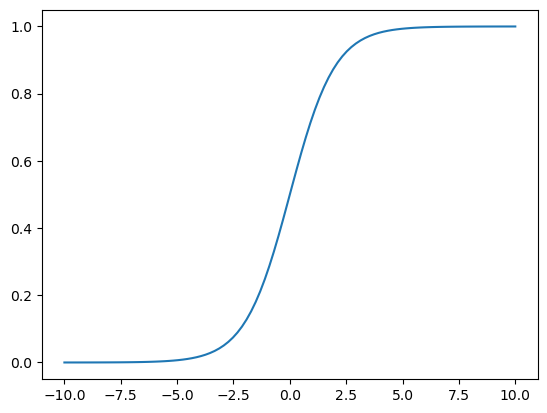

In [99]:
# sigmoid
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)

### Meshgrids
